# AI-Accelerated QEC for Neutral-Atom Logical Qubits

This interactive companion to Infleqtion’s [AI-accelerated QEC post](https://infleqtion.com/ai-accelerated-qec/) turns its leakage-aware NVIDIA Ising Decoding experiment into runnable cells. It keeps the experiment deliberately transparent: change the leakage probabilities, number of shots, and execution mode, regenerate the metrics, and inspect the resulting logical-error-rate and decoder-latency plots.

> **Heuristic simulation.** This notebook injects leakage transitions after two-qubit Clifford gates on top of a fixed circuit-level Pauli noise model for a distance-9 surface-code memory experiment. It is an exploration tool, not a hardware-calibrated prediction.

## Why decoding matters

QEC is both a quantum and a classical-computing problem. Every correction round creates syndrome data that must be processed fast enough to keep pace with the hardware. NVIDIA Ising Decoding provides a learned GPU-resident pass that sparsifies syndrome information before downstream decoding, reducing the classical burden while retaining information needed for correction.

For neutral atoms, this is especially relevant as measurement and control loops become faster: useful logical qubits require accuracy, throughput, and low decoding latency together.

## Neutral atoms are qubits in theory, but qudits in practice

Neutral-atom hardware can occupy levels outside the computational subspace. In this simplified model, `|0L⟩` and `|1L⟩` leak out of the computational space but are still read as 0-like and 1-like outcomes. The decoder therefore sees leakage indirectly through a syndrome stream shaped by both Pauli-type noise and out-of-subspace population.

Run the next cell to explore that binary readout mapping.

In [1]:
def map_readout_state(level: int) -> int:
    """Map computational and leakage levels to a binary readout."""
    zero_like = {0, 2}  # |0⟩ and |0L⟩
    one_like = {1, 3}   # |1⟩ and |1L⟩
    if level in zero_like:
        return 0
    if level in one_like:
        return 1
    raise ValueError(f"Unexpected state label: {level}")

for level, label in enumerate(("|0⟩", "|1⟩", "|0L⟩", "|1L⟩")):
    print(f"{label:4} → observed binary outcome {map_readout_state(level)}")

|0⟩  → observed binary outcome 0
|1⟩  → observed binary outcome 1
|0L⟩ → observed binary outcome 0
|1L⟩ → observed binary outcome 1


## Experiment setup

This tutorial is run from the checked-out repository, including `third_party/ising-decoding`. The local model is NVIDIA's public pretrained Chamberland `PreDecoderModelMemory_v1` checkpoint, stored through Git LFS. Create a project-local GPU environment before opening the notebook:

```bash
cd ~/Ieee_qec_26_tutorial
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install torch numpy matplotlib pymatching deltakit-stim jupyterlab ipykernel stim
python -m ipykernel install --user --name ieee-qec --display-name "Python (IEEE QEC)"
```

Launch Jupyter from this same directory with `.venv` activated, then select the Python (IEEE QEC) kernel. Confirm `torch.cuda.is_available()` is `True` before running the pipeline. Install Git LFS before cloning so the checkpoint is a real PyTorch file rather than an LFS pointer. This notebook uses **Deltakit-Stim**, not `leaky`: it converts detected leakage into heralded-erasure flags. The frozen Chamberland CNN consumes only its original four syndrome channels; the residual syndrome, erasure flags, and raw readout features are passed to the global neural decoder.

In [2]:
import re
import os
import subprocess
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})
%config InlineBackend.figure_format = 'retina'

In [3]:
repo_dir = Path.cwd().resolve()
ising_dir = repo_dir / "third_party/ising-decoding"
scripts_dir = ising_dir / "code/scripts"
checkpoint = ising_dir / "models/Ising-Decoder-SurfaceCode-1-Fast.pt"
data_dir = repo_dir / "data"
output_dir = repo_dir / "outputs"
if not checkpoint.exists():
    raise RuntimeError("Missing Chamberland checkpoint. Run `git lfs install` then `git lfs pull` in third_party/ising-decoding.")
print(f"Using frozen Chamberland checkpoint: {checkpoint}")
print(f"Deltakit/NN tutorial scripts: {scripts_dir}")

Using frozen Chamberland checkpoint: /home/ubuntu/Ieee_qec_26_tutorial/third_party/ising-decoding/models/Ising-Decoder-SurfaceCode-1-Fast.pt
Deltakit/NN tutorial scripts: /home/ubuntu/Ieee_qec_26_tutorial/third_party/ising-decoding/code/scripts


## Run controls

The notebook trains live by default on CUDA. Each run creates fresh Deltakit-Stim training and held-out shards, freezes the pretrained Chamberland local CNN, trains a new global MLP, evaluates it, and plots the live held-out result. Select smoke only to test the wiring quickly.

In [4]:
# Run these cells in order on a CUDA kernel.
EXECUTION_MODE = "gpu"  # choose "smoke" or "gpu"
RUN_SEED = None  # None creates a fresh random training/held-out split; set an integer to reproduce it.

if EXECUTION_MODE == "smoke":
    SHOTS, EPOCHS, BATCH_SIZE = 4_096, 3, 256
elif EXECUTION_MODE == "gpu":
    SHOTS, EPOCHS, BATCH_SIZE = 65_536, 20, 256
else:
    raise ValueError("EXECUTION_MODE must be 'smoke' or 'gpu'.")

print({"mode": EXECUTION_MODE, "shots": SHOTS, "epochs": EPOCHS, "batch_size": BATCH_SIZE, "seed": RUN_SEED})

{'mode': 'gpu', 'shots': 65536, 'epochs': 20, 'batch_size': 256, 'seed': None}


In [5]:
# Deltakit-Stim → frozen Chamberland CNN → global neural decoder.
runner_python = repo_dir / ".venv/bin/python"
if not runner_python.is_file():
    raise RuntimeError(f"Create the project environment first: python3 -m venv {repo_dir / '.venv'}")

script_env = os.environ | {"PYTHONPATH": str(ising_dir / "code")}

def run(script, *args, capture=False):
    command = [str(runner_python), str(scripts_dir / script), *map(str, args)]
    print("$", " ".join(command))
    completed = subprocess.run(
        command, cwd=repo_dir, env=script_env, check=True, text=True,
        stdout=subprocess.PIPE if capture else None,
        stderr=subprocess.STDOUT if capture else None,
    )
    if capture:
        print(completed.stdout, end="")
    return completed.stdout

run_seed = int(np.random.SeedSequence().generate_state(1)[0]) if RUN_SEED is None else RUN_SEED
suffix = f"d9_{EXECUTION_MODE}"
circuit_shard = data_dir / f"loss_aware_{suffix}_train.npz"
heldout_circuit_shard = data_dir / f"loss_aware_{suffix}_heldout.npz"
residual_shard = data_dir / f"bluvstein_residual_{suffix}_train.npz"
heldout_residual_shard = data_dir / f"bluvstein_residual_{suffix}_heldout.npz"
global_checkpoint = output_dir / f"bluvstein_global_{suffix}.pt"

dataset_args = ("--distance", 9, "--rounds", 9, "--pauli-p", 0.002, "--erasure-p", 0.01, "--teacher", "circuit-frame")
run("generate_loss_aware_dataset.py", *dataset_args, "--shots", SHOTS, "--seed", run_seed, "--output", circuit_shard)
run("generate_loss_aware_dataset.py", *dataset_args, "--shots", max(512, SHOTS // 8), "--seed", run_seed + 1, "--output", heldout_circuit_shard)

predecoder_args = (checkpoint, "--device", "cuda", "--batch-size", BATCH_SIZE, "--balance-logical-labels")
run("generate_bluzstein_residual_dataset.py", circuit_shard, *predecoder_args, "--seed", run_seed, "--output", residual_shard)
run("generate_bluzstein_residual_dataset.py", heldout_circuit_shard, *predecoder_args, "--seed", run_seed + 1, "--output", heldout_residual_shard)

run("train_bluvstein_global_decoder.py", residual_shard, "--device", "cuda", "--batch-size", BATCH_SIZE, "--epochs", EPOCHS, "--output", global_checkpoint)
evaluation_stdout = run("evaluate_bluvstein_global_decoder.py", heldout_residual_shard, global_checkpoint, "--device", "cuda", capture=True)
metrics = dict(re.findall(r"^(BCE|global residual accuracy|final logical LER): ([0-9.]+)$", evaluation_stdout, flags=re.MULTILINE))
result = {
    "dataset": f"fresh Deltakit-Stim d=9 shard ({SHOTS:,} training shots; seed={run_seed})",
    "global_decoder": "newly trained Bluvstein-style MLP after frozen Chamberland CNN",
    "heldout_bce": float(metrics["BCE"]),
    "heldout_global_accuracy": float(metrics["global residual accuracy"]),
    "heldout_logical_failure": float(metrics["final logical LER"]),
}

Pipeline Python: /home/ubuntu/Ieee_qec_26_tutorial/.venv/bin/python
Generating a fresh Deltakit-Stim split with seed=4186571496.
$ /home/ubuntu/Ieee_qec_26_tutorial/.venv/bin/python /home/ubuntu/Ieee_qec_26_tutorial/third_party/ising-decoding/code/scripts/generate_loss_aware_dataset.py --distance 9 --rounds 9 --shots 65536 --pauli-p 0.002 --erasure-p 0.01 --seed 4186571496 --teacher circuit-frame --output /home/ubuntu/Ieee_qec_26_tutorial/data/loss_aware_d9_gpu_train.npz
wrote /home/ubuntu/Ieee_qec_26_tutorial/data/loss_aware_d9_gpu_train.npz
train_x shape: (65536, 5, 9, 9, 9)
local_teacher_y shape: (65536, 4, 9, 9, 9)
heralded erasures: 477121
$ /home/ubuntu/Ieee_qec_26_tutorial/.venv/bin/python /home/ubuntu/Ieee_qec_26_tutorial/third_party/ising-decoding/code/scripts/generate_loss_aware_dataset.py --distance 9 --rounds 9 --shots 8192 --pauli-p 0.002 --erasure-p 0.01 --seed 4186571497 --teacher circuit-frame --output /home/ubuntu/Ieee_qec_26_tutorial/data/loss_aware_d9_gpu_heldout.npz

## Results: loss-aware AI decoding

The implemented path is Deltakit-Stim → frozen Chamberland local CNN → Bluvstein-style global MLP. Deltakit-Stim converts the leakage event into a known erasure location. The Chamberland model processes only its original four syndrome channels and returns a residual syndrome plus a local logical frame. The global MLP receives that residual, the herald map, and raw measurement/readout features, then predicts the remaining logical parity.

The final logical sign is S_L = S_L^(local) XOR S_L^(global). This MLP is the tutorial's global AI decoder; loss-aware PyMatching remains a useful exact, deterministic reference baseline, but is not the downstream stage in this pipeline. The plot below uses the newly trained model's balanced held-out logical-classification result, not a physical-error-rate threshold claim.

In [6]:
# `result` is created by the live evaluation cell above; no stored data are loaded here.
# The software logical flip balances the binary global-label task, so chance accuracy is 50%.
if "result" not in globals():
    raise RuntimeError("Run the live pipeline cell first so this plot uses a newly trained decoder.")
for name, value in result.items():
    print(f"{name}: {value}")

dataset: fresh Deltakit-Stim d=9 shard (65,536 training shots; seed=4186571496)
global_decoder: newly trained Bluvstein-style MLP after frozen Chamberland CNN
heldout_bce: 0.575
heldout_global_accuracy: 0.904785
heldout_logical_failure: 0.0952148


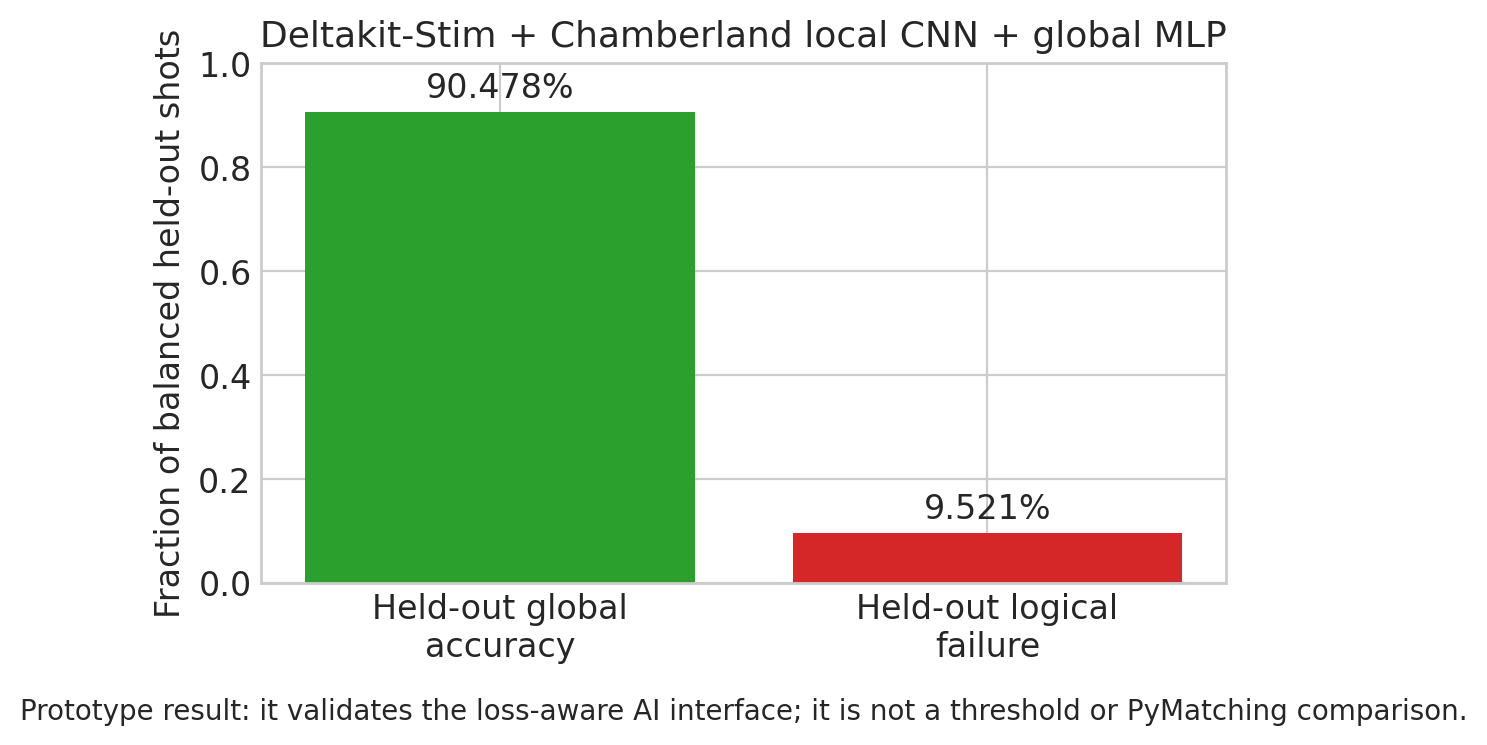

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")
labels = ["Held-out global\naccuracy", "Held-out logical\nfailure"]
values = [result["heldout_global_accuracy"], result["heldout_logical_failure"]]
colors = ["tab:green", "tab:red"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, labels=[f"{value:.3%}" for value in values], padding=3)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of balanced held-out shots")
ax.set_title("Deltakit-Stim + Chamberland local CNN + global MLP")
ax.text(0.5, -0.22, "Prototype result: it validates the loss-aware AI interface; it is not a threshold or PyMatching comparison.",
        ha="center", va="top", transform=ax.transAxes, fontsize=10)
fig.tight_layout()
plt.show()

## From leakage to erasure

Leakage is not always an opaque error channel. Here, Deltakit-Stim turns each detected leakage event into a heralded-erasure flag. The flag does not reveal which Pauli occurred, but it tells the decoder where the uncertainty is concentrated. It is therefore passed unchanged to the global neural decoder alongside the Chamberland-predecoded residual.

This is deliberately not a retrained loss-aware Chamberland local CNN: a detected loss/reset has no unique local Pauli-correction label. Instead, the pretrained local CNN keeps its established task, while the global MLP learns the unambiguous remaining logical parity using both residual syndrome and erasure context. A herald-conditioned PyMatching decoder is retained in the repository as an optional correctness/reference baseline.

## Why this matters for Sqale

The broader objective is a coherent hybrid QPU–GPU stack: strong physical qubits, scalable logical architectures, GPU-resident classical acceleration, and AI models that make control and decoding faster and more informed. For neutral atoms, Deltakit-Stim supplies a simple circuit-level heralded-leakage model, while the two-stage neural decoder illustrates local preprocessing followed by global loss-aware inference.

Read the full [published post](https://infleqtion.com/ai-accelerated-qec/) for the neutral-atom context, platform roadmap, and source figures. This notebook is the executable companion for the loss-aware AI-decoding experiment.

In [ ]:
Loo